<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


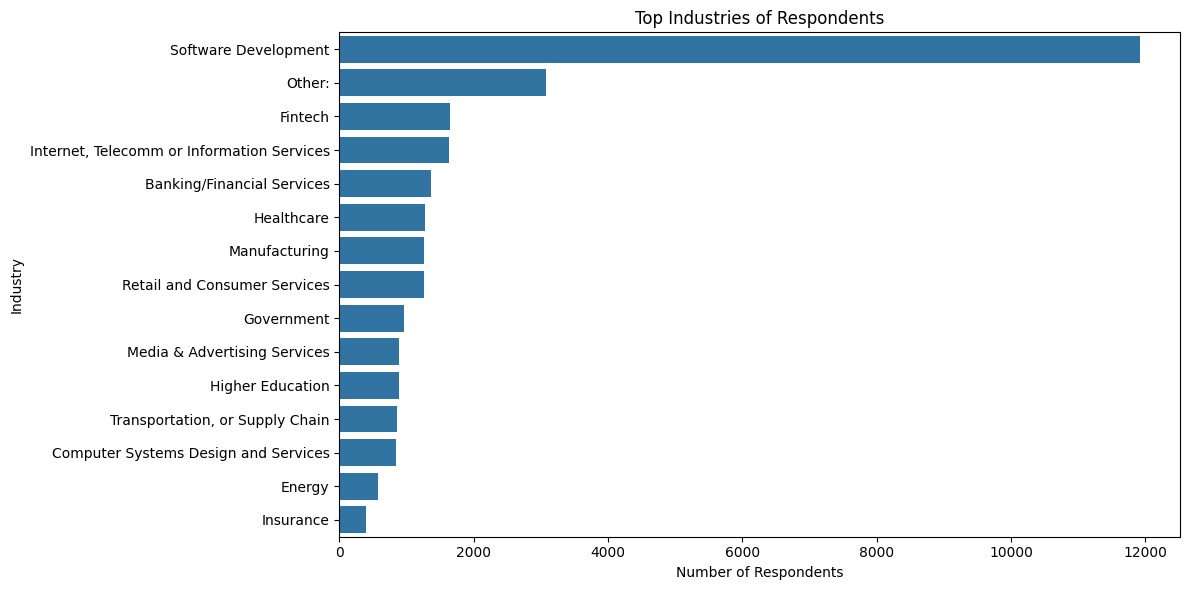

In [7]:
##Write your code here

import matplotlib.pyplot as plt
import seaborn as sns

# Count respondents by industry
industry_counts = (
    df['Industry']
    .value_counts()
    .head(15)   # Top 15 industries
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index
)

plt.title('Top Industries of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')

plt.tight_layout()
plt.show()

Most responders are from the software development industry

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [9]:
# Basic statistics for yearly compensation and threshold

stats = df['ConvertedCompYearly'].agg(['mean', 'median', 'std'])

threshold = stats['mean'] + 3 * stats['std']

print(stats)
print("\nOutlier threshold (mean + 3*std):", threshold)

mean       86155.287263
median     65000.000000
std       186756.973086
Name: ConvertedCompYearly, dtype: float64

Outlier threshold (mean + 3*std): 646426.2065215341

Number of extreme compensation cases: 89

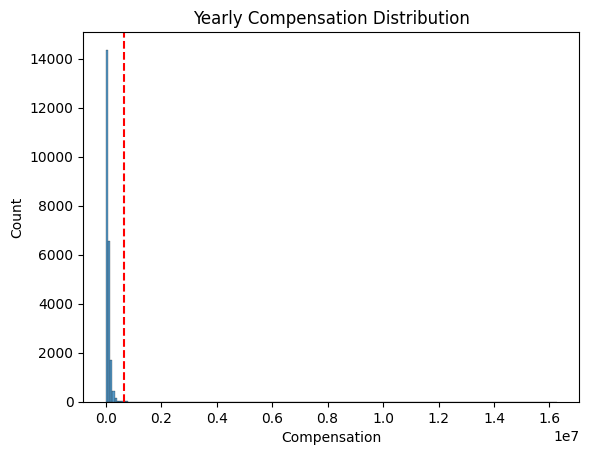

In [13]:
# Identify outliers and visualize

outliers = df[df['ConvertedCompYearly'] > threshold]

print("Number of extreme compensation cases:", outliers.shape[0])

sns.histplot(df['ConvertedCompYearly'], bins=200)
plt.axvline(threshold, color='red', linestyle='--')
plt.title('Yearly Compensation Distribution')
plt.xlabel('Compensation')
plt.ylabel('Count')
plt.show()

Performed computed summary statistics for yearly compensation, defined an outlier threshold using 3 standard deviations above the mean, and identified/highlighted respondents exceeding this threshold (very few)

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [14]:
# Identify outliers in the ConvertedCompYearly column using the IQR method.

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ConvertedCompYearly'] < lower_bound) | 
              (df['ConvertedCompYearly'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of outliers: 978

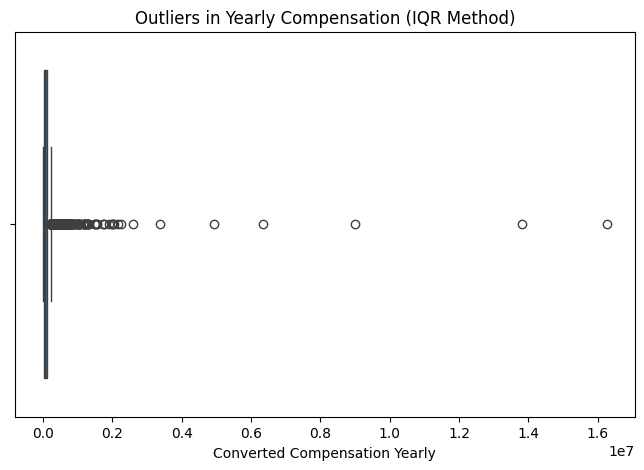

In [15]:
# Visualization with boxplot

plt.figure(figsize=(8,5))

sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Outliers in Yearly Compensation (IQR Method)')
plt.xlabel('Converted Compensation Yearly')

plt.show()

The IQR method was applied to identify outliers in yearly compensation by computing quartiles, defining lower and upper bounds, and visualizing extreme values using a box plot.

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [16]:
# IQR-based outlier removal for ConvertedCompYearly

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

print("Original dataset size:", df.shape)
print("Clean dataset size (no outliers):", df_no_outliers.shape)
print("Rows removed:", df.shape[0] - df_no_outliers.shape[0])

Original dataset size: (65437, 114)
Clean dataset size (no outliers): (22457, 114)
Rows removed: 42980

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [17]:
# Map Age to numeric (midpoints approximation)

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df_age = df.copy()
df_age['Age_num'] = df_age['Age'].map(age_map)

# Select numerical columns (safe subset)
num_cols = df_age.select_dtypes(include=['float64', 'int64']).columns

# Correlation matrix
corr_matrix = df_age[num_cols].corr()

# Correlation of Age with other numeric variables
age_corr = corr_matrix['Age_num'].sort_values(ascending=False)

print(age_corr)

Age_num                1.000000
WorkExp                0.850866
ConvertedCompYearly    0.121474
JobSat                 0.069908
CompTotal             -0.002764
JobSatPoints_1        -0.027975
ResponseId            -0.037923
JobSatPoints_8        -0.046182
JobSatPoints_6        -0.050314
JobSatPoints_4        -0.075979
JobSatPoints_9        -0.081673
JobSatPoints_7        -0.082747
JobSatPoints_5        -0.101526
JobSatPoints_11       -0.107149
JobSatPoints_10       -0.114361
Name: Age_num, dtype: float64

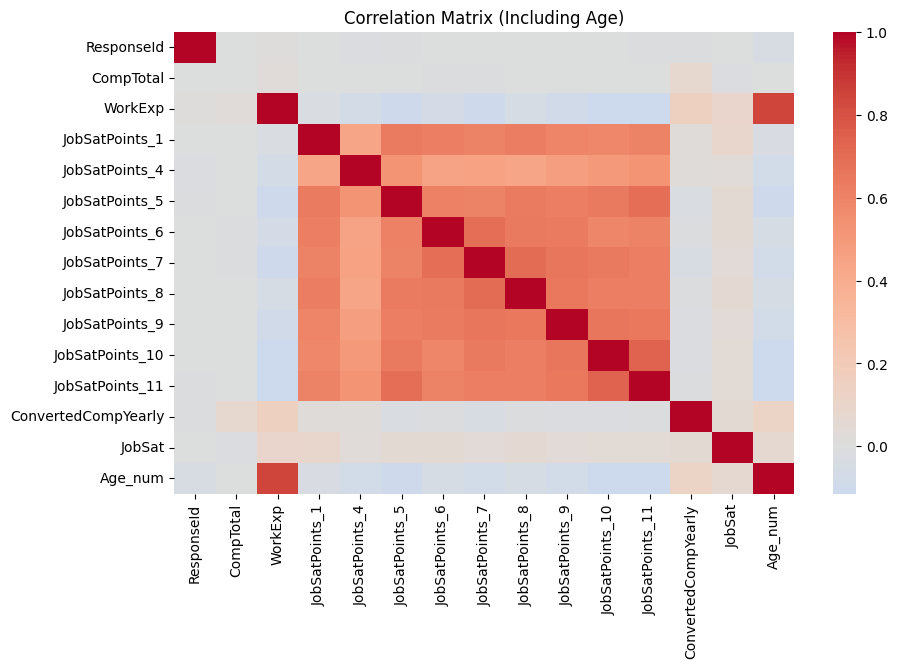

In [18]:
# Heatmap for visualization

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix (Including Age)')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
